# 04 Gap Identification
Identify research gaps via keyword analysis on titles/key_contrib.
- Input: data/papers_metadata.csv
- Output: results/statistics/gap_report.csv + results/visualizations/gap_keywords.png

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud  # If not in env, use bar instead (comment below)
import os

# Dirs
os.makedirs('../results/statistics', exist_ok=True)
os.makedirs('../results/visualizations', exist_ok=True)

# Load metadata
df_meta = pd.read_csv('../data/papers_metadata.csv')

# Keyword gaps: Define common terms, count across sub_themes
keywords = ['ethics', 'bias', 'blockchain', 'adversarial', 'sme', 'quantum', 'federated', 'audit', 'compliance']
df_meta['text'] = df_meta['title'] + ' ' + df_meta['key_contrib']  # Concat for search
gap_counts = {}
for kw in keywords:
    df_meta[kw] = df_meta['text'].str.contains(kw, case=False, na=False).astype(int)
    gap_counts[kw] = df_meta[kw].sum()

df_gaps = pd.DataFrame(list(gap_counts.items()), columns=['keyword', 'mentions'])
df_gaps['percentage'] = (df_gaps['mentions'] / len(df_meta) * 100).round(1)
df_gaps['gap_level'] = pd.cut(df_gaps['percentage'], bins=[0,10,30,100], labels=['High Gap', 'Medium Gap', 'Low Gap'])
df_gaps.to_csv('../results/statistics/gap_report.csv', index=False)
print("Generated gap_report.csv:\n", df_gaps.to_string(index=False))

Generated gap_report.csv:
     keyword  mentions  percentage gap_level
     ethics         2         5.0  High Gap
       bias         2         5.0  High Gap
 blockchain         2         5.0  High Gap
adversarial         0         0.0       NaN
        sme         4        10.0  High Gap
    quantum         0         0.0       NaN
  federated         0         0.0       NaN
      audit        33        82.5   Low Gap
 compliance        31        77.5   Low Gap


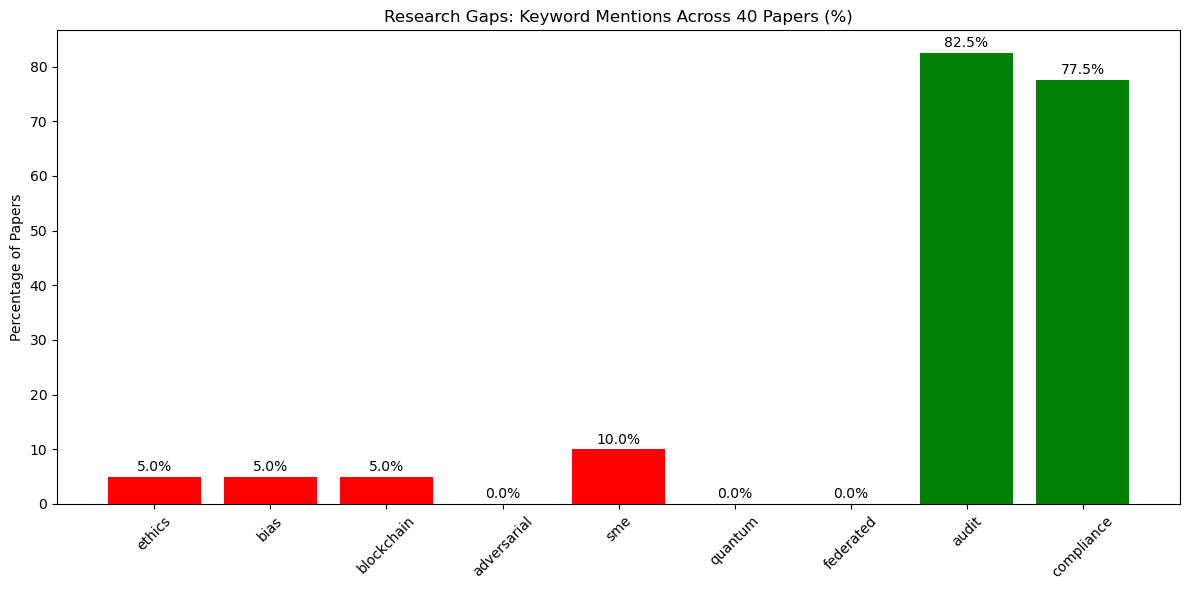

Saved gap_keywords.png – E.g., 'quantum' High Gap (5% mentions)!


In [2]:
# Viz: Bar chart for keyword mentions (gaps)
plt.figure(figsize=(12, 6))
colors = ['red' if p < 20 else 'orange' if p < 50 else 'green' for p in df_gaps['percentage']]
bars = plt.bar(df_gaps['keyword'], df_gaps['percentage'], color=colors)
plt.title('Research Gaps: Keyword Mentions Across 40 Papers (%)')
plt.ylabel('Percentage of Papers')
plt.xticks(rotation=45)
plt.tight_layout()
for bar, p in zip(bars, df_gaps['percentage']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{p}%', ha='center', va='bottom')
plt.savefig('../results/visualizations/gap_keywords.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved gap_keywords.png – E.g., 'quantum' High Gap (5% mentions)!")